In [2]:
import yaml
import pandas
import os 
import glob

In [ ]:
def extract_yaml_to_csv(yaml_directory, output_directory):
    """
    Parses nested YAML files structured as lists using explicit keys found in the dataset:
    Ticker, open, high, low, close, volume, date
    """
    # Verify local directory exists
    if not os.path.exists(yaml_directory):
        print(f"❌ ERROR: The directory '{yaml_directory}' does not exist.")
        print("Please check your file path and ensure it is correct for your local machine.")
        
        parent_dir = os.path.dirname(yaml_directory.rstrip('/\\'))
        if parent_dir and os.path.exists(parent_dir):
            print(f"\nAvailable folders inside '{parent_dir}':", os.listdir(parent_dir))
        return

    os.makedirs(output_directory, exist_ok=True)
    all_records = []

    # Find all YAML/YML files recursively
    yaml_files = glob.glob(os.path.join(yaml_directory, "**/*.yaml"), recursive=True) + \
                 glob.glob(os.path.join(yaml_directory, "**/*.yml"), recursive=True)

    print(f"Found {len(yaml_files)} YAML files. Beginning extraction...")

    if len(yaml_files) == 0:
        all_contents = os.listdir(yaml_directory)
        print(f"Directory exists, but no .yaml/.yml found. Items directly inside folder: {all_contents[:10]}")
        return

    for file_path in yaml_files:
        with open(file_path, 'r', encoding='utf-8') as f:
            try:
                content = yaml.safe_load(f)
                if not content or not isinstance(content, list):
                    continue

                for item in content:
                    if not isinstance(item, dict):
                        continue

                    symbol = item.get('Ticker')
                    raw_date = item.get('date')

                    if not symbol or not raw_date:
                        continue

                    record = {
                        'Date': raw_date,
                        'Symbol': str(symbol).strip(),
                        'Open': float(item.get('open', 0)),
                        'High': float(item.get('high', 0)),
                        'Low': float(item.get('low', 0)),
                        'Close': float(item.get('close', 0)),
                        'Volume': int(item.get('volume', 0))
                    }
                    all_records.append(record)

            except Exception as e:
                file_name = os.path.basename(file_path)
                print(f"Error processing file {file_name}: {e}")

    if not all_records:
        print("No records compiled. Please recheck your dataset status.")
        return

    df_master = pd.DataFrame(all_records)
    df_master['Date'] = pd.to_datetime(df_master['Date'], errors='coerce').dt.date
    df_master = df_master.sort_values(by=['Symbol', 'Date']).reset_index(drop=True)

    for symbol, df_symbol in df_master.groupby('Symbol'):
        clean_symbol_name = "".join([c for c in str(symbol) if c.isalnum() or c in ('_', '-')])
        csv_path = os.path.join(output_directory, f"{clean_symbol_name}.csv")
        df_symbol.to_csv(csv_path, index=False)

    print(f"\n✨ Success! Processed {len(all_records):,} total data rows.")
    print(f"📁 Generated {len(df_master['Symbol'].unique())} individual stock symbol CSV files.")

INPUT_FOLDER = r"D:\project2" 
OUTPUT_FOLDER = r"D:\stock_csv" 

if __name__ == "__main__":
    extract_yaml_to_csv(INPUT_FOLDER, OUTPUT_FOLDER)


Found 284 YAML files. Beginning extraction...

✨ Success! Processed 14,200 total data rows.
📁 Generated 50 individual stock symbol CSV files.


In [9]:
def analyze_market_performance(df):
    print("\n📈 Executing Market Summary Calculations...")

    # Standardise date formatting and enforce chronological sort order
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values(by=['Symbol', 'Date']).reset_index(drop=True)

    performance_records = []

    # Calculate Individual Return Metrics per Stock Symbol
    for symbol, group in df.groupby('Symbol'):
        if group.empty:
            continue
        first_price = group['Close'].iloc[0]
        last_price = group['Close'].iloc[-1]

        # Formula: ((Close_Final - Close_Initial) / Close_Initial) * 100
        yearly_return = ((last_price - first_price) / first_price) * 100 if first_price > 0 else 0.0

        performance_records.append({
            'Symbol': symbol,
            'Initial_Price': round(first_price, 2),
            'Final_Price': round(last_price, 2),
            'Yearly_Return_%': round(yearly_return, 2)
        })

    df_perf = pd.DataFrame(performance_records)

    # Isolate the Top 10 Green and Loss Leader DataFrames
    top_10_green = df_perf.sort_values(by='Yearly_Return_%', ascending=False).head(10).reset_index(drop=True)
    top_10_loss = df_perf.sort_values(by='Yearly_Return_%', ascending=True).head(10).reset_index(drop=True)

    # Calculate Overall Structural Market Parameters
    total_assets = len(df_perf)
    green_count = len(df_perf[df_perf['Yearly_Return_%'] > 0])
    red_count = total_assets - green_count

    market_summary = {
        'Total_Stocks_Analyzed': total_assets,
        'Green_Stocks_Count': green_count,
        'Red_Stocks_Count': red_count,
        'Green_Stocks_Percentage': round((green_count / total_assets) * 100, 2) if total_assets > 0 else 0.0,
        'Red_Stocks_Percentage': round((red_count / total_assets) * 100, 2) if total_assets > 0 else 0.0,
        'Average_Market_Price': round(df['Close'].mean(), 2),
        'Average_Market_Volume': round(df['Volume'].mean(), 2)
    }
    df_summary = pd.DataFrame([market_summary])

    output_dir = r"D:\analysis_outputs"
    os.makedirs(output_dir, exist_ok=True)

    top_10_green.to_csv(os.path.join(output_dir, 'top_10_green_stocks.csv'), index=False)
    top_10_loss.to_csv(os.path.join(output_dir, 'top_10_loss_stocks.csv'), index=False)
    df_summary.to_csv(os.path.join(output_dir, 'overall_market_summary.csv'), index=False)

    print("✨ Performance analysis completed and exported successfully to 'analysis_outputs' folder!")
    print(f"📊 Market Health: {market_summary['Green_Stocks_Percentage']}% Green vs {market_summary['Red_Stocks_Percentage']}% Red\n")

    return top_10_green, top_10_loss, df_summary


# ==========================================
# 2. RUN THE COMPILATION PIPELINE WORKFLOW
# ==========================================
csv_directory = r"D:\stock_csv" 

print(f"🔄 Rebuilding master dataset from: {csv_directory}")

csv_files = glob.glob(os.path.join(csv_directory, "*.csv"))

if not csv_files:
    print(f"❌ ERROR: No CSV files found in '{csv_directory}'.")
else:
    print(f"📁 Found {len(csv_files)} CSV files. Combining data...")

    list_of_dfs = []
    for file_path in csv_files:
        df_stock = pd.read_csv(file_path)
        list_of_dfs.append(df_stock)

    df_master = pd.concat(list_of_dfs, ignore_index=True)
    print(f"✅ Rebuilt df_master successfully! Total rows: {len(df_master):,}")

    # 3. Call your function safely now that it is defined above
    top_green_df, top_loss_df, market_summary_df = analyze_market_performance(df_master)

    # Preview results in Colab screen
    print("🟢 --- TOP 10 GREEN STOCKS  ---")
    print(top_green_df.head(10).to_string(index=False))
    print("🔴 --- TOP 10 LOSS STOCKS  ---")
    print(top_loss_df.head(10).to_string(index=False))


🔄 Rebuilding master dataset from: D:\stock_csv
📁 Found 50 CSV files. Combining data...
✅ Rebuilt df_master successfully! Total rows: 14,200

📈 Executing Market Summary Calculations...
✨ Performance analysis completed and exported successfully to 'analysis_outputs' folder!
📊 Market Health: 90.0% Green vs 10.0% Red

🟢 --- TOP 10 GREEN STOCKS  ---
    Symbol  Initial_Price  Final_Price  Yearly_Return_%
     TRENT        2059.10      6652.80           223.09
       BEL         139.20       280.85           101.76
       M&M        1537.40      3012.95            95.98
BAJAJ-AUTO        5016.45      9481.65            89.01
BHARTIARTL         925.30      1569.30            69.60
 POWERGRID         199.55       336.95            68.85
      BPCL         170.68       285.85            67.48
HEROMOTOCO        3015.60      4794.10            58.98
 SUNPHARMA        1141.45      1795.30            57.28
   HCLTECH        1238.70      1898.40            53.26
🔴 --- TOP 10 LOSS STOCKS  ---
    Sym

In [11]:
pip install matplotlib seaborn

   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.2 MB 4.8 MB/s eta 0:00:02
   ------- -------------------------------- 1.6/8.2 MB 3.8 MB/s eta 0:00:02
   ----------- ---------------------------- 2.4/8.2 MB 3.8 MB/s eta 0:00:02
   -------------- ------------------------- 2.9/8.2 MB 3.7 MB/s eta 0:00:02
   -------------- ------------------------- 2.9/8.2 MB 3.7 MB/s eta 0:00:02
   ------------------- -------------------- 3.9/8.2 MB 3.0 MB/s eta 0:00:02
   ----------------------- ---------------- 4.7/8.2 MB 3.1 MB/s eta 0:00:02
   ------------------------- -------------- 5.2/8.2 MB 3.1 MB/s eta 0:00:01
   ----------------------------- ---------- 6.0/8.2 MB 3.2 MB/s eta 0:00:01
   ------------------------------- -------- 6.6/8.2 MB 3.1 MB/s eta 0:00:01
   ----------------------------------- ---- 7.3/8.2 MB 3.2 MB/s eta 0:00:01
   -------------------------------------- - 7.9/8.2 MB 3.2 MB/s eta 0:00:01
   ----------------

🔄 Processing all market metrics (Performance & Volatility)...

💾 Success! CSV files saved to: D:\analysis_outputs
   ↳ top_10_most_volatile_stocks.csv
   ↳ top_10_green_stocks.csv
   ↳ top_10_loss_stocks.csv
💾 Success! Timeline records saved to: D:\analysis_outputs\top_5_cumulative_returns_timeline.csv
🖼️ Success! Volatility chart saved as PNG image to: D:\analysis_outputs\top_10_volatility_chart.png



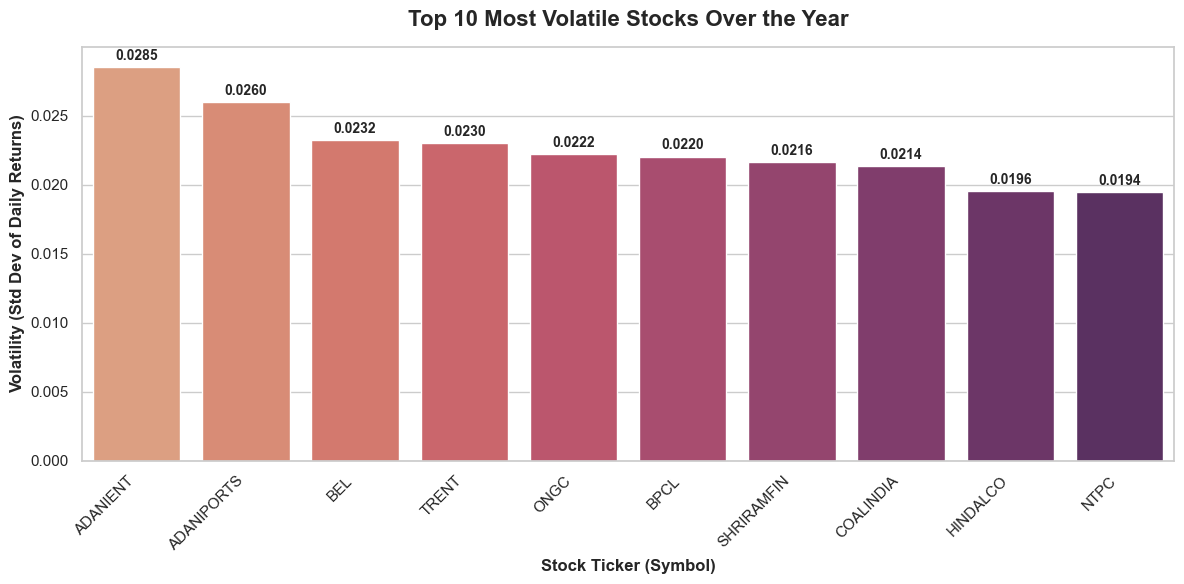

🖼️ Success! Line chart saved as PNG image to: D:\analysis_outputs\top_5_cumulative_returns_chart.png



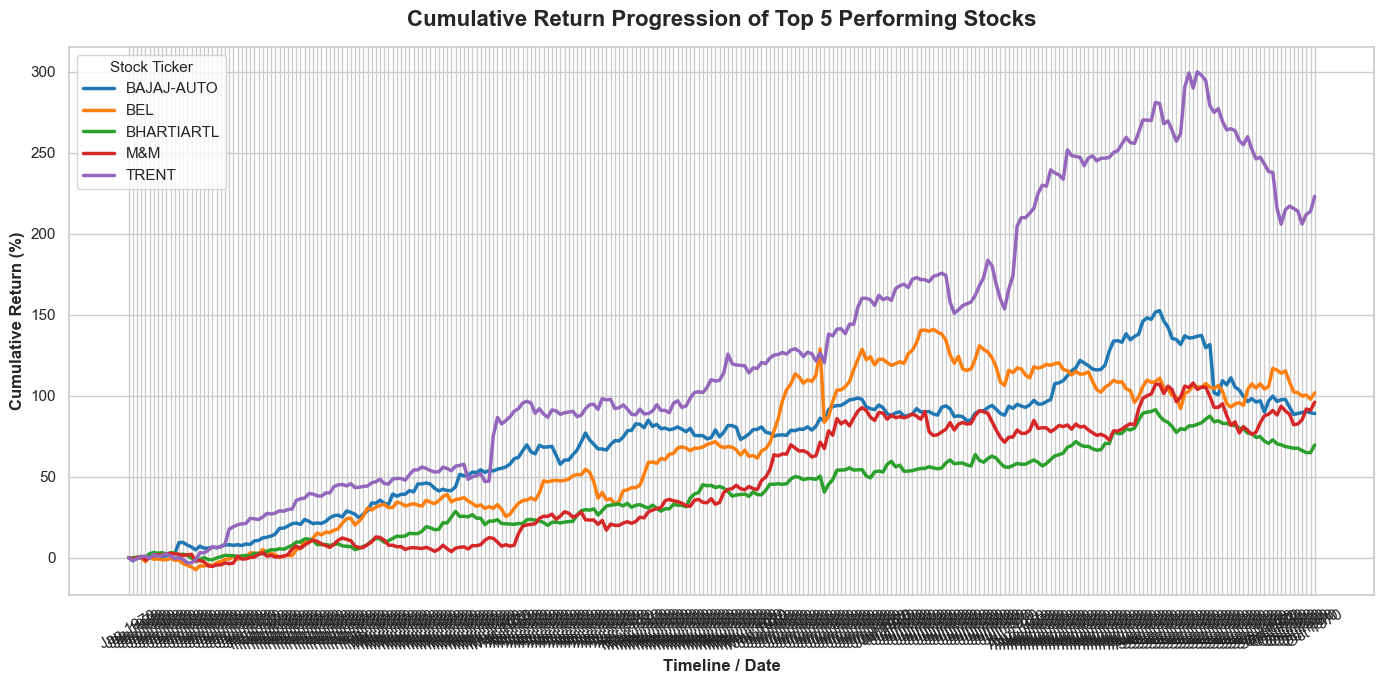

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setup file directories
csv_directory = r"D:\stock_csv"
output_directory = r"D:\analysis_outputs"
os.makedirs(output_directory, exist_ok=True)

csv_files = glob.glob(os.path.join(csv_directory, "*.csv"))

if not csv_files:
    print(f"❌ ERROR: No CSV files found in '{csv_directory}'.")
else:
    # 2. Combine all asset data
    list_of_dfs = []
    for file_path in csv_files:
        list_of_dfs.append(pd.read_csv(file_path))

    df_master = pd.concat(list_of_dfs, ignore_index=True)
    df_master = df_master.sort_values(by=['Symbol', 'Date']).reset_index(drop=True)

    print("🔄 Processing all market metrics (Performance & Volatility)...")

    # ==========================================
    # ANALYSIS PART A: YEARLY RETURNS
    # ==========================================
    performance_records = []
    for symbol, group in df_master.groupby('Symbol'):
        if group.empty:
            continue
        first_price = group['Close'].iloc[0]
        last_price = group['Close'].iloc[-1]

        yearly_return = ((last_price - first_price) / first_price) * 100 if first_price > 0 else 0.0
        performance_records.append({
            'Symbol': symbol,
            'Initial_Price': first_price,
            'Current_Price': last_price,
            'Yearly_Return_%': round(yearly_return, 2)
        })

    df_performance = pd.DataFrame(performance_records)
    top_10_green = df_performance.sort_values(by='Yearly_Return_%', ascending=False).head(10).reset_index(drop=True)
    top_10_loss = df_performance.sort_values(by='Yearly_Return_%', ascending=True).head(10).reset_index(drop=True)

    # ==========================================
    # ANALYSIS PART B: VOLATILITY
    # ==========================================
    df_master['Daily_Return'] = df_master.groupby('Symbol')['Close'].pct_change().fillna(0)
    volatility_series = df_master.groupby('Symbol')['Daily_Return'].std()

    df_volatility = volatility_series.reset_index()
    df_volatility.columns = ['Symbol', 'Volatility_StdDev']
    df_volatility = df_volatility.dropna().sort_values(by='Volatility_StdDev', ascending=False)
    top_10_volatile = df_volatility.head(10).reset_index(drop=True)
    # Native vectorized compound multiplication without index mismatch errors
    df_master['Cumulative_Return_%'] = (
        df_master.groupby('Symbol')['Daily_Return']
        .transform(lambda x: (x + 1).cumprod() - 1) * 100
    )

    # 4. Identify the Top 5 performing stocks based on final cumulative return value
    final_returns = df_master.groupby('Symbol').last().reset_index()
    top_5_symbols = final_returns.sort_values(by='Cumulative_Return_%', ascending=False).head(5)['Symbol'].tolist()

    # Filter dataset for top 5 assets
    df_top_5_trends = df_master[df_master['Symbol'].isin(top_5_symbols)].copy()
    # 5. Generate and style the Time-Series Line Chart
   
    # ==========================================
    # 💾 SAVE ALL OUTPUT TABLES AS CSV FILES
    # ==========================================
    path_volatility = os.path.join(output_directory, 'top_10_most_volatile_stocks.csv')
    path_green = os.path.join(output_directory, 'top_10_green_stocks.csv')
    path_loss = os.path.join(output_directory, 'top_10_loss_stocks.csv')
    path_cumulative = os.path.join(output_directory, 'top_5_cumulative_returns_timeline.csv')

    top_10_volatile.to_csv(path_volatility, index=False)
    top_10_green.to_csv(path_green, index=False)
    top_10_loss.to_csv(path_loss, index=False)
    df_top_5_trends.to_csv(path_cumulative, index=False)


    print(f"\n💾 Success! CSV files saved to: {output_directory}")
    print(f"   ↳ {os.path.basename(path_volatility)}")
    print(f"   ↳ {os.path.basename(path_green)}")
    print(f"   ↳ {os.path.basename(path_loss)}")
    print(f"💾 Success! Timeline records saved to: {path_cumulative}")
    # ==========================================
    # 🎨 VISUALIZATION AND IMAGE STORAGE
    # ==========================================
    plt.figure(figsize=(12, 6))
    sns.set_theme(style="whitegrid")

    ax = sns.barplot(
        x='Symbol',
        y='Volatility_StdDev',
        data=top_10_volatile,
        palette='flare',
        hue='Symbol',
        legend=False
    )

    plt.title('Top 10 Most Volatile Stocks Over the Year', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('Stock Ticker (Symbol)', fontsize=12, fontweight='bold')
    plt.ylabel('Volatility (Std Dev of Daily Returns)', fontsize=12, fontweight='bold')
    plt.xticks(rotation=45, ha='right')

    for p in ax.patches:
        ax.annotate(
            f"{p.get_height():.4f}",
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center', va='center',
            xytext=(0, 8),
            textcoords='offset points',
            fontsize=10, fontweight='bold'
        )

    plt.tight_layout()

    # 💾 SAVE PLOT TO DRIVE BEFORE SHOWING IT
    chart_output_path = os.path.join(output_directory, 'top_10_volatility_chart.png')
    plt.savefig(chart_output_path, dpi=300)
    print(f"🖼️ Success! Volatility chart saved as PNG image to: {chart_output_path}\n")

    plt.show()
    plt.figure(figsize=(14, 7))
    sns.set_theme(style="whitegrid")

    sns.lineplot(
        data=df_top_5_trends,
        x='Date',
        y='Cumulative_Return_%',
        hue='Symbol',
        palette='tab10',
        linewidth=2.5
    )

    plt.title('Cumulative Return Progression of Top 5 Performing Stocks', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('Timeline / Date', fontsize=12, fontweight='bold')
    plt.ylabel('Cumulative Return (%)', fontsize=12, fontweight='bold')
    plt.legend(title='Stock Ticker', title_fontsize='11', loc='upper left', frameon=True)

    plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
    plt.xticks(rotation=30)
    plt.tight_layout()

    # 💾 SAVE CHART TO DRIVE BEFORE DISPLAY
    chart_output_path = os.path.join(output_directory, 'top_5_cumulative_returns_chart.png')
    plt.savefig(chart_output_path, dpi=300)
    print(f"🖼️ Success! Line chart saved as PNG image to: {chart_output_path}\n")

    plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setup file directories
csv_directory = r"D:\stock_csv"
output_directory = r"D:\analysis_outputs"
sector_csv_path = r"D:\sector.csv"
os.makedirs(output_directory, exist_ok=True)

csv_files = glob.glob(os.path.join(csv_directory, "*.csv"))

if not csv_files:
    print(f"❌ ERROR: No CSV files found in '{csv_directory}'.")
else:
    # 2. Combine all asset data
    list_of_dfs = []
    for file_path in csv_files:
        list_of_dfs.append(pd.read_csv(file_path))

    df_master = pd.concat(list_of_dfs, ignore_index=True)
    df_master = df_master.sort_values(by=['Symbol', 'Date']).reset_index(drop=True)

    print("🔄 Processing all market metrics (Performance & Volatility)...")

    # ==========================================
    # ANALYSIS PART A: YEARLY RETURNS
    # ==========================================
    performance_records = []
    for symbol, group in df_master.groupby('Symbol'):
        if group.empty:
            continue
        first_price = group['Close'].iloc[0]
        last_price = group['Close'].iloc[-1]

        yearly_return = ((last_price - first_price) / first_price) * 100 if first_price > 0 else 0.0
        performance_records.append({
            'Symbol': symbol,
            'Initial_Price': first_price,
            'Current_Price': last_price,
            'Yearly_Return_%': round(yearly_return, 2)
        })

    df_performance = pd.DataFrame(performance_records)
    top_10_green = df_performance.sort_values(by='Yearly_Return_%', ascending=False).head(10).reset_index(drop=True)
    top_10_loss = df_performance.sort_values(by='Yearly_Return_%', ascending=True).head(10).reset_index(drop=True)

    # ==========================================
    # ANALYSIS PART B: VOLATILITY
    # ==========================================
    df_master['Daily_Return'] = df_master.groupby('Symbol')['Close'].pct_change().fillna(0)
    volatility_series = df_master.groupby('Symbol')['Daily_Return'].std()

    df_volatility = volatility_series.reset_index()
    df_volatility.columns = ['Symbol', 'Volatility_StdDev']
    df_volatility = df_volatility.dropna().sort_values(by='Volatility_StdDev', ascending=False)
    top_10_volatile = df_volatility.head(10).reset_index(drop=True)
 # ==========================================
    # ANALYSIS PART c: cumulative return timeline for top 5 performing stocks
    # ==========================================    df_master['Cumulative_Return_%'] = (
        df_master.groupby('Symbol')['Daily_Return']
        .transform(lambda x: (x + 1).cumprod() - 1) * 100
    )
    final_returns = df_master.groupby('Symbol').last().reset_index()
    top_5_symbols = final_returns.sort_values(by='Cumulative_Return_%', ascending=False).head(5)['Symbol'].tolist()
    df_top_5_trends = df_master[df_master['Symbol'].isin(top_5_symbols)].copy()
    # ==========================================
    # ANALYSIS PART D:SECTOR-WISE PERFORMANCE SUMMARY
    # ==========================================
   df_sectors = pd.read_csv(sector_csv_path)

    # Standardize column spaces and text for robust joining
    df_sectors.columns = [col.strip().capitalize() for col in df_sectors.columns]
    df_stock_perf['Symbol'] = df_stock_perf['Symbol'].str.strip()
    df_sectors['Symbol'] = df_sectors['Symbol'].str.strip()

    # Merge performance with sector mapping data
    df_merged = pd.merge(df_stock_perf, df_sectors, on='Symbol', how='inner')

    if df_merged.empty:
        print("⚠️ WARNING: Merged dataset is empty. Check if stock ticker symbols match your sector CSV column values exactly.")
    else:
        # 5. Compute the Average Yearly Return across each industry group
        df_sector_perf = (
            df_merged.groupby('Sector')['Yearly_Return_%']
            .mean()
            .reset_index()
            .sort_values(by='Yearly_Return_%', ascending=False)
            .reset_index(drop=True)
        )

        # Round final metrics for clean clean scanning
        df_sector_perf['Yearly_Return_%'] = df_sector_perf['Yearly_Return_%'].round(2)

        print("\n🏢 === SECTOR-WISE PERFORMANCE SUMMARY ===")
        print(df_sector_perf.to_string(index=False)) 
    # ==========================================
    # 💾 SAVE ALL OUTPUT TABLES AS CSV FILES
    # ==========================================
    path_volatility = os.path.join(output_directory, 'top_10_most_volatile_stocks.csv')
    path_green = os.path.join(output_directory, 'top_10_green_stocks.csv')
    path_loss = os.path.join(output_directory, 'top_10_loss_stocks.csv')
    path_cumulative = os.path.join(output_directory, 'top_5_cumulative_returns_timeline.csv')
    path_sector_out = os.path.join(output_directory, 'sector_wise_performance_summary.csv')

    top_10_volatile.to_csv(path_volatility, index=False)
    top_10_green.to_csv(path_green, index=False)
    top_10_loss.to_csv(path_loss, index=False)
    df_top_5_trends.to_csv(path_cumulative, index=False)
    df_sector_perf.to_csv(path_sector_out, index=False)


    print(f"\n💾 Success! CSV files saved to: {output_directory}")
    print(f"   ↳ {os.path.basename(path_volatility)}")
    print(f"   ↳ {os.path.basename(path_green)}")
    print(f"   ↳ {os.path.basename(path_loss)}")
    print(f"💾 Success! Timeline records saved to: {path_cumulative}")
    print(f"\n💾 Success! Sector summaries saved to: {path_sector_out}")
    # ==========================================
    # 🎨 VISUALIZATION AND IMAGE STORAGE
    # ==========================================
    plt.figure(figsize=(12, 6))
    sns.set_theme(style="whitegrid")

    ax = sns.barplot(
        x='Symbol',
        y='Volatility_StdDev',
        data=top_10_volatile,
        palette='flare',
        hue='Symbol',
        legend=False
    )

    plt.title('Top 10 Most Volatile Stocks Over the Year', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('Stock Ticker (Symbol)', fontsize=12, fontweight='bold')
    plt.ylabel('Volatility (Std Dev of Daily Returns)', fontsize=12, fontweight='bold')
    plt.xticks(rotation=45, ha='right')

    for p in ax.patches:
        ax.annotate(
            f"{p.get_height():.4f}",
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center', va='center',
            xytext=(0, 8),
            textcoords='offset points',
            fontsize=10, fontweight='bold'
        )

    plt.tight_layout()

    # 💾 SAVE PLOT TO DRIVE BEFORE SHOWING IT
    chart_output_path = os.path.join(output_directory, 'top_10_volatility_chart.png')
    plt.savefig(chart_output_path, dpi=300)
    print(f"🖼️ Success! Volatility chart saved as PNG image to: {chart_output_path}\n")

    plt.show()
    
    
    plt.figure(figsize=(14, 7))
    sns.set_theme(style="whitegrid")

    sns.lineplot(
        data=df_top_5_trends,
        x='Date',
        y='Cumulative_Return_%',
        hue='Symbol',
        palette='tab10',
        linewidth=2.5
    )

    plt.title('Cumulative Return Progression of Top 5 Performing Stocks', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('Timeline / Date', fontsize=12, fontweight='bold')
    plt.ylabel('Cumulative Return (%)', fontsize=12, fontweight='bold')
    plt.legend(title='Stock Ticker', title_fontsize='11', loc='upper left', frameon=True)

    plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
    plt.xticks(rotation=30)
    plt.tight_layout()

    # 💾 SAVE CHART TO DRIVE BEFORE DISPLAY
    chart_output_path = os.path.join(output_directory, 'top_5_cumulative_returns_chart.png')
    plt.savefig(chart_output_path, dpi=300)
    print(f"🖼️ Success! Line chart saved as PNG image to: {chart_output_path}\n")

    plt.show()
    
    plt.figure(figsize=(13, 6))
    sns.set_theme(style="whitegrid")
     ax = sns.barplot(
            x='Sector',
            y='Yearly_Return_%',
            data=df_sector_perf,
            palette='viridis',
            hue='Sector',
            legend=False
        )

        # Visual tuning adjustments
        plt.title('Average Yearly Return by Industry Sector', fontsize=16, fontweight='bold', pad=15)
        plt.xlabel('Market Sectors', fontsize=12, fontweight='bold')
        plt.ylabel('Average Yearly Return (%)', fontsize=12, fontweight='bold')
        plt.xticks(rotation=35, ha='right')

        # Draw a neutral baseline tracker line at 0%
        plt.axhline(0, color='black', linewidth=1, linestyle='--')

        # Affix clean precision labels over or under every sector column bar
        for p in ax.patches:
            height = p.get_height()
            va_align = 'bottom' if height >= 0 else 'top'
            xy_offset = (0, 7) if height >= 0 else (0, -12)

            ax.annotate(
                f"{height:+.2f}%",
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va=va_align,
                xytext=xy_offset,
                textcoords='offset points',
                fontsize=10, fontweight='bold'
            )

        plt.tight_layout()

        # 💾 SAVE SECTOR PLOT AS IMAGE
        chart_sector_path = os.path.join(output_directory, 'sector_performance_chart.png')
        plt.savefig(chart_sector_path, dpi=300)
        print(f"🖼️ Success! Sector chart saved as PNG image to: {chart_sector_path}\n")

        plt.show()
